# 02. Baseline clásico: HOG + SVM


La estrategia consiste en extraer características visuales mediante HOG (Histogram of Oriented Gradients) y entrenar un clasificador SVM con kernel lineal para distinguir entre frutas frescas y podridas.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [5]:
project_root_candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path(r'C:\Users\alfam\proyPercepcion'),
]
project_root = None
for candidate in project_root_candidates:
    if (candidate / 'data' / 'train').exists() and (candidate / 'data' / 'test').exists():
        project_root = candidate
        break

if project_root is None:
    project_root = Path(r'C:\Users\alfam\proyPercepcion')

train_dir = project_root / 'data' / 'train'
test_dir = project_root / 'data' / 'test'

print(f'Ruta del proyecto: {project_root}')
print(f'Train existe: {train_dir.exists()}')
print(f'Test existe: {test_dir.exists()}')

if not train_dir.exists() or not test_dir.exists():
    print('El dataset no está disponible en la ruta esperada.')
    print('Verifica que el notebook esté ejecutándose con el kernel local de Windows.')

Ruta del proyecto: c:\Users\alfam\proyPercepcion
Train existe: True
Test existe: True


In [6]:
def extraer_hog(ruta_img, size=(64, 64)):
    """Extrae características HOG de una imagen en escala de grises."""
    img = cv2.imread(str(ruta_img))
    img = cv2.resize(img, size)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    hog = cv2.HOGDescriptor(
        _winSize=(64, 64),
        _blockSize=(16, 16),
        _blockStride=(8, 8),
        _cellSize=(8, 8),
        _nbins=9
    )
    features = hog.compute(img_gray)
    return features.flatten()

def cargar_dataset(data_dir, max_images_per_class=None):
    """Carga imágenes desde data_dir y retorna matrices X e y."""
    X, y = [], []
    class_dirs = sorted([p for p in data_dir.iterdir() if p.is_dir()])

    for class_dir in class_dirs:
        etiqueta = 'fresh' if 'fresh' in class_dir.name.lower() else 'rotten'
        image_files = [p for p in sorted(class_dir.iterdir()) if p.is_file()]
        if max_images_per_class is not None:
            image_files = image_files[:max_images_per_class]

        for img_path in image_files:
            try:
                feat = extraer_hog(img_path)
                X.append(feat)
                y.append(etiqueta)
            except Exception:
                pass

    return np.array(X), np.array(y)

print('Funciones HOG definidas correctamente.')

Funciones HOG definidas correctamente.


Cargando datos completos...
X_train: (10901, 1764)
X_test: (2698, 1764)
Accuracy baseline HOG+SVM: 80.84%
\nReporte de clasificación:
              precision    recall  f1-score   support

       fresh       0.79      0.76      0.77      1164
      rotten       0.82      0.84      0.83      1534

    accuracy                           0.81      2698
   macro avg       0.81      0.80      0.80      2698
weighted avg       0.81      0.81      0.81      2698



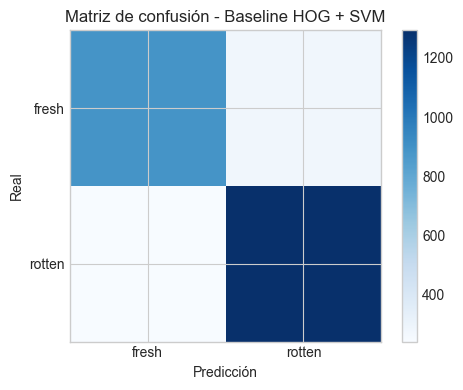

In [7]:
if train_dir.exists() and test_dir.exists():
    print('Cargando datos completos...')
    X_train, y_train = cargar_dataset(train_dir)
    X_test, y_test = cargar_dataset(test_dir)

    print(f'X_train: {X_train.shape}')
    print(f'X_test: {X_test.shape}')

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    svm = SVC(kernel='linear', C=1.0)
    svm.fit(X_train, y_train_enc)

    y_pred = svm.predict(X_test)
    acc = accuracy_score(y_test_enc, y_pred)
    print(f'Accuracy baseline HOG+SVM: {acc * 100:.2f}%')
    print('\\nReporte de clasificación:')
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test_enc, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap='Blues')
    plt.title('Matriz de confusión - Baseline HOG + SVM')
    plt.xticks([0, 1], le.classes_)
    plt.yticks([0, 1], le.classes_)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print('No se puede entrenar el baseline porque faltan data/train o data/test.')